In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("MallData.csv")
print("File imported Successfully")

File imported Successfully


In [3]:
df.shape

(15079, 5)

In [6]:
df.describe

<bound method NDFrame.describe of                                 Customer ID  Age  Gender  Annual Income  \
0      d410ea53-6661-42a9-ad3a-f554b05fd2a7   30    Male         151479   
1      1770b26f-493f-46b6-837f-4237fb5a314e   58  Female         185088   
2      e81aa8eb-1767-4b77-87ce-1620dc732c5e   62  Female          70912   
3      9795712a-ad19-47bf-8886-4f997d6046e3   23    Male          55460   
4      64139426-2226-4cd6-bf09-91bce4b4db5e   24    Male         153752   
...                                     ...  ...     ...            ...   
15074  a0504768-a85f-4930-ac24-55bc8e4fec9e   29  Female          97723   
15075  a08c4e0e-d1fe-48e7-9366-aab11ae409cd   22    Male          73361   
15076  0e87c25a-268c-401a-8ba1-7111dcde6f1a   18  Female         112337   
15077  5f388cbe-3373-4e16-b743-38f508f2249f   26  Female          94312   
15078  b8b8f561-ebca-4401-8afe-544c906554ba   19    Male          78045   

       Spending Score  
0                  89  
1                

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB


In [8]:
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [9]:
df.isnull().sum()

Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

In [19]:
df.columns

Index(['Age', 'Gender', 'Annual Income', 'Spending Score'], dtype='object')

In [1]:
# StandardScaler : Tool used to scale data so all features are on same range.

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

In [22]:
#LabelEncoder() : converts text data into number
#fit() : learns the data patteerns 
#transform() : convert data to standard scale

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print("Done")

Done


In [24]:
# StandardScaler() : Creates scaler object

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


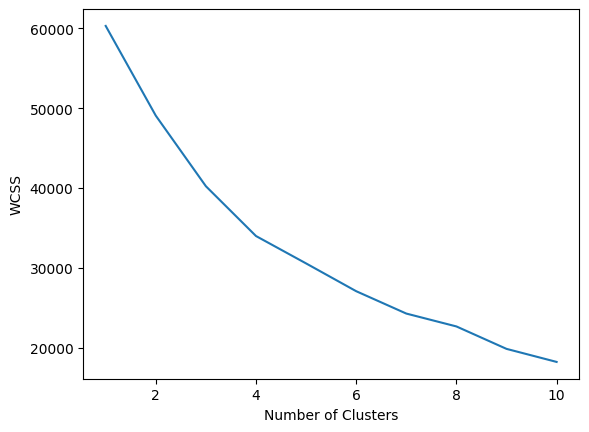

In [25]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [26]:
# KMeans() → Creates KMeans clustering model.

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_data)


In [34]:
#df['Cluster'] : Creates a new column named Cluster

df['Cluster'] = clusters
df.head(20)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             15079 non-null  int64
 1   Gender          15079 non-null  int64
 2   Annual Income   15079 non-null  int64
 3   Spending Score  15079 non-null  int64
 4   Cluster         15079 non-null  int32
dtypes: int32(1), int64(4)
memory usage: 530.2 KB


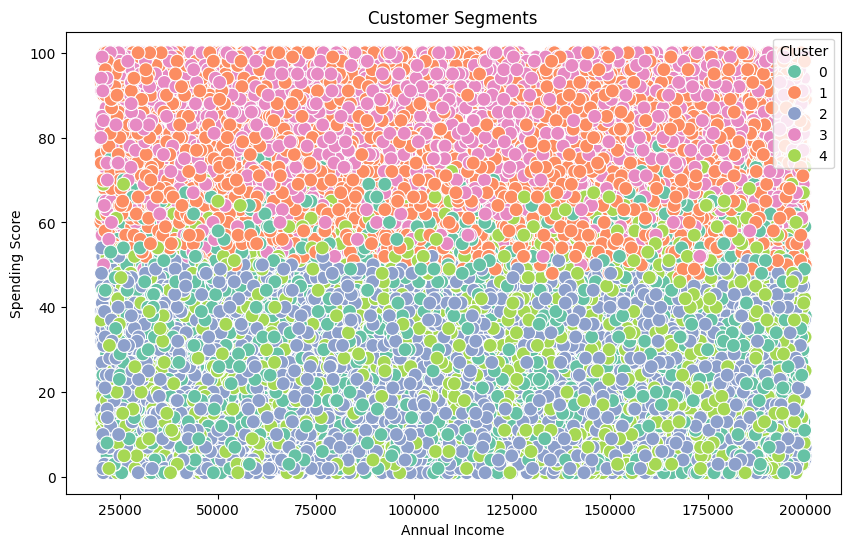

In [30]:

plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income',
                y='Spending Score',
                hue='Cluster',
                palette='Set2',
                data=df,
                s=100)

plt.title("Customer Segments")
plt.show()


In [33]:
df['Cluster'].value_counts()


Cluster
1    3845
2    3750
3    2770
0    2382
4    2332
Name: count, dtype: int64

In [35]:

df.to_csv('Mall_Customers_GMM_Segmented.csv', index=False)
print("Results saved! Ready for business use.")

Results saved! Ready for business use.
